Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [ ]:
# Формуємо послідовність років за допомогою numpy.arange
# Від 1960 до 2000 включно з кроком 10
indexes = np.arange(1960, 2010, 10)
json_files = [f'movies-{i}s.json' for i in indexes]
json_dir = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/"
dataframes = []


2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [ ]:
# Проходимося по кожному файлу зі списку json_files
for file in json_files:

    # Формуємо повний шлях до JSON-файлу
    file_path = json_dir + file

    try:
        # Зчитуємо JSON-файл у DataFrame
        df = pd.read_json(file_path)

    except Exception as e:
        # Якщо файл не зчитався — виводимо повідомлення про помилку
        print(f"Could not read {file_path}: {e}")
        continue

    # Список колонок, які не потрібні для подальшого аналізу
    drop_columns = ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']

    # Видаляємо зайві колонки (навіть якщо деяких з них немає)
    df = df.drop(columns=drop_columns, errors='ignore')

    # Видаляємо рядки з пропущеними значеннями
    df = df.dropna()

    # Додаємо підготовлений DataFrame у список dataframes
    dataframes.append(df)

# Після завершення циклу об'єднуємо всі датафрейми в один
final_movies_df = pd.concat(dataframes, ignore_index=True)

# Після завершення циклу об'єднуємо всі датафрейми в один
combined = pd.concat(dataframes, ignore_index=True)

# Виводимо датафрейм, щоб з'явилася таблиця
combined

,title,year,cast,genres
0,The 3rd Voice,1960,"[Edmond O'Brien, Laraine Day, Julie London]","[Mystery, Crime, Drama, Noir, Thriller]"
1,12 to the Moon,1960,"[Ken Clark, Tom Conway]","[Science Fiction, Independent]"
2,13 Fighting Men,1960,"[Grant Williams, Carole Matthews]","[War, Drama]"
3,13 Ghosts,1960,"[Charles Herbert, Jo Morrow]","[Horror, Supernatural]"
4,The Adventures of Huckleberry Finn,1960,"[Tony Randall, Patty McCormack, Eddie Hodges, ...","[Family, Drama]"
...,...,...,...,...
10745,The Imaginarium of Doctor Parnassus,2009,"[Heath Ledger, Christopher Plummer, Verne Troy...",[Fantasy]
10746,It's Complicated,2009,"[Meryl Streep, Steve Martin, Alec Baldwin, Joh...","[Comedy, Romance]"
10747,Sherlock Holmes,2009,"[Robert Downey Jr., Jude Law, Rachel McAdams, ...","[Action, Mystery, Historical]"
10748,The Loss of a Teardrop Diamond,2009,"[Bryce Dallas Howard, Chris Evans, Ellen Burst...",[Independent]


3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [ ]:
# Зберігаємо об'єднаний DataFrame у CSV-файл
combined.to_csv('movies_data.csv', index=False)

# Виводимо розмір підсумкової таблиці
print('Shape:', combined.shape)

# За потреби присвоюємо combined у df для подальшої роботи
df = combined

Shape: (10750, 4)


4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [ ]:
# Перевіряємо вміст перших рядочків датасету
display(df.head())

# Використовуємо метод info для перевірки структури та типів даних
df.info()

,title,year,cast,genres
0,The 3rd Voice,1960,"[Edmond O'Brien, Laraine Day, Julie London]","[Mystery, Crime, Drama, Noir, Thriller]"
1,12 to the Moon,1960,"[Ken Clark, Tom Conway]","[Science Fiction, Independent]"
2,13 Fighting Men,1960,"[Grant Williams, Carole Matthews]","[War, Drama]"
3,13 Ghosts,1960,"[Charles Herbert, Jo Morrow]","[Horror, Supernatural]"
4,The Adventures of Huckleberry Finn,1960,"[Tony Randall, Patty McCormack, Eddie Hodges, ...","[Family, Drama]"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10750 entries, 0 to 10749
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   10750 non-null  object
 1   year    10750 non-null  int64 
 2   cast    10750 non-null  object
 3   genres  10750 non-null  object
dtypes: int64(1), object(3)
memory usage: 336.1+ KB


5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.


 Top 10 genres:
             genre  movies_count
0           Comedy          3777
1            Drama          3758
2           Action          1228
3         Thriller          1158
4           Horror          1044
5          Romance           948
6            Crime           873
7  Science Fiction           708
8        Adventure           556
9          Western           492


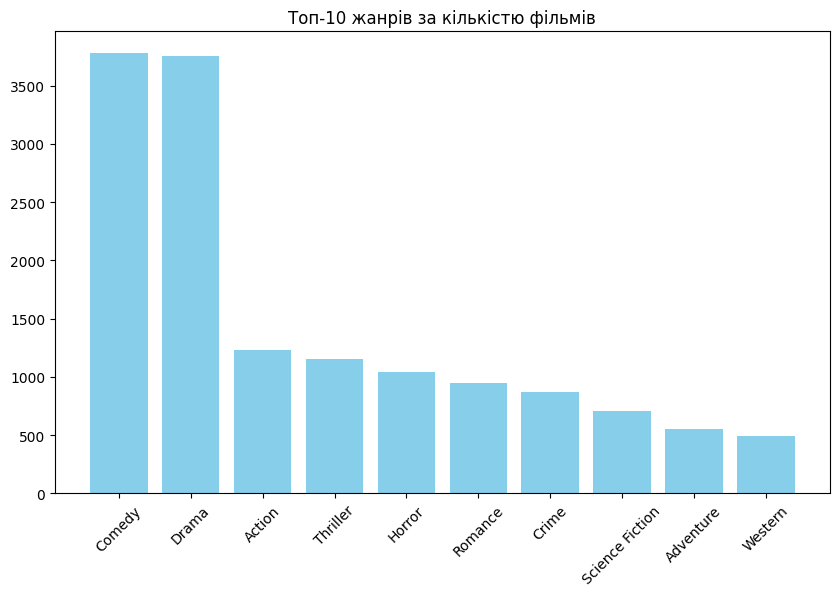

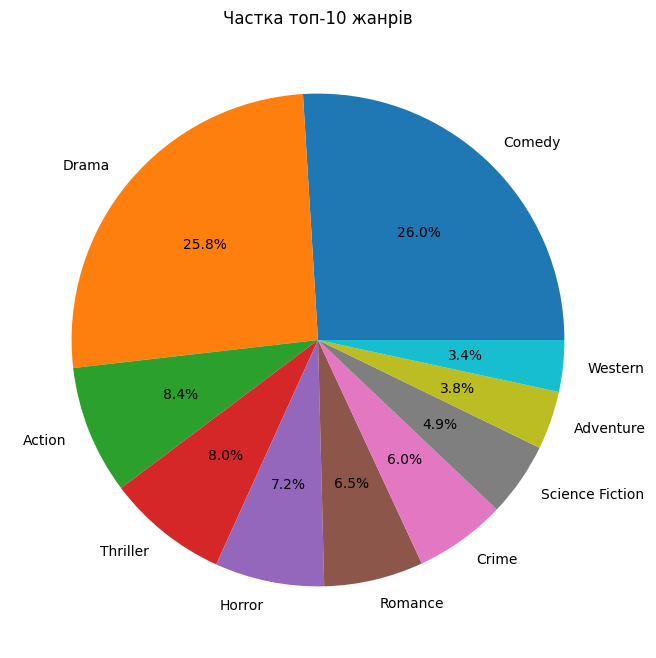

In [ ]:
# Перетворюємо значення в колонці genres:
# якщо це рядок — приводимо його до списку, якщо ні — залишаємо без змін
df['genres'] = df['genres'].apply(lambda x: x if isinstance(x, list) else [])

# "Розгортаємо" списки жанрів так, щоб кожен жанр був в окремому рядку
df_exploded = df.explode('genres')

# Прибираємо рядки, де genre відсутній
df_exploded = df_exploded[df_exploded['genres'].notna()]

# Рахуємо кількість фільмів у кожному жанрі
genre_counts = df_exploded['genres'].value_counts() \
    .reset_index() \
    .sort_values(by='count', ascending=False)

# Перейменовуємо колонки для зрозумілості
genre_counts.columns = ['genre', 'movies_count']

# Виводимо результат (таблицю)
print('\n Top 10 genres:')
print(genre_counts.head(10))

# --- ВІЗУАЛІЗАЦІЯ ---

# Беремо топ-10 для графіків
top_10_genres = genre_counts.head(10)

# Стовпчикова діаграма
plt.figure(figsize=(10, 6))
plt.bar(top_10_genres['genre'], top_10_genres['movies_count'], color='skyblue')
plt.title('Топ-10 жанрів за кількістю фільмів')
plt.xticks(rotation=45)
plt.show()

# Кругова діаграма
plt.figure(figsize=(8, 8))
plt.pie(top_10_genres['movies_count'], labels=top_10_genres['genre'], autopct='%1.1f%%')
plt.title('Частка топ-10 жанрів')
plt.show()

6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [ ]:
# Визначаємо топ 3 жанрів (беремо їх з нашої попередньої таблиці genre_counts)
top3 = genre_counts['genre'].head(3).tolist()

# Виводимо вибрані жанри для перевірки
print("Вибрані жанри:")
print(top3, "\n")

# Фільтруємо df_exploded, залишаємо тільки обрані топ-3 жанри
df_top = df_exploded[df_exploded["genres"].isin(top3)]

# Групуємо по роках і жанрах та підраховуємо кількість фільмів
trend = df_top.groupby(["year", "genres"]).size().reset_index(name="movies_count")

# Перевіряємо частину результату
print("Тренд по роках:")
print(trend.head(), "\n")

Вибрані жанри:
['Comedy', 'Drama', 'Action'] 

Тренд по роках:
   year  genres  movies_count
0  1960  Action             4
1  1960  Comedy            30
2  1960   Drama            63
3  1961  Action             5
4  1961  Comedy            42 



Pivot-таблиця:
genres  Action  Comedy  Drama
year                         
1960         4      30     63
1961         5      42     74
1962         2      38     63
1963         2      55     42
1964         3      54     46 



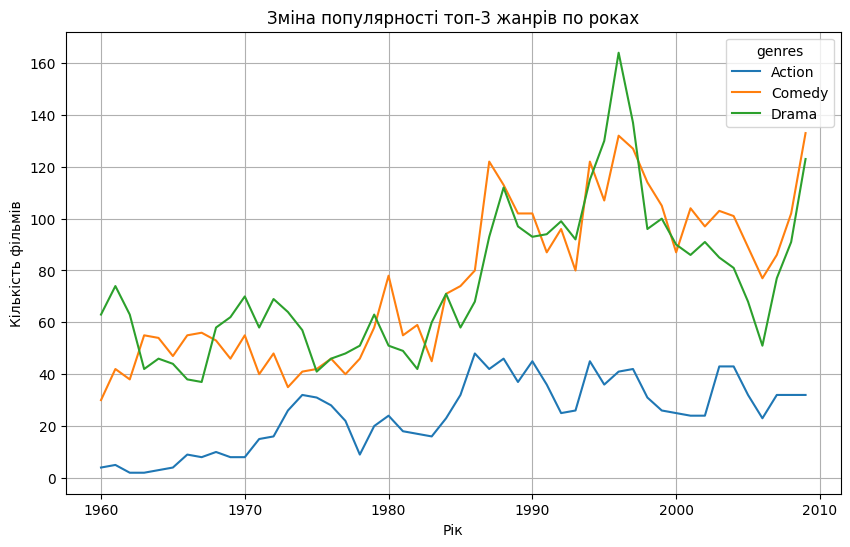

In [ ]:
# Перетворюємо DataFrame у зручний формат для аналізу (Pivot Table)
trend_pivot = trend.pivot(index='year', columns='genres', values='movies_count')

# Виводимо частину таблиці для перевірки
print("Pivot-таблиця:")
print(trend_pivot.head(), "\n")

# Будуємо лінійний графік
trend_pivot.plot(figsize=(10, 6))

# Додаємо оформлення
plt.title('Зміна популярності топ-3 жанрів по роках')
plt.xlabel('Рік')
plt.ylabel('Кількість фільмів')
plt.grid(True)
plt.show()

7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

In [ ]:
# Перетворюємо колонку з акторами у списки Python
# (Страховка на випадок, якщо там не список)
df["cast"] = df["cast"].apply(lambda x: x if isinstance(x, list) else [])

# Створюємо порожній список для всіх акторів
all_actors = []

# Проходимо по кожному фільму і додаємо акторів до єдиного списку
for sublist in df["cast"]:
    for actor in sublist:
        all_actors.append(actor)

# Рахуємо, скільки разів зустрічається кожен актор
# Перетворюємо список у Series, рахуємо значення і скидаємо індекс, щоб отримати DataFrame
actor_counts = pd.Series(all_actors).value_counts().reset_index()

# Перейменовуємо колонки для зручності
actor_counts.columns = ['actor', 'movies_count']

# Вибираємо топ акторів (кількість вибираєте самі, нам треба топ-10)
top_actors = actor_counts.head(10)

# Виводимо результат
print('\n Top 10 Actors:')
print(top_actors)


 Top 10 Actors:
                actor  movies_count
0        Gene Hackman            71
1       Robert Duvall            68
2      Robert De Niro            65
3       Burt Reynolds            63
4       Harvey Keitel            58
5  Christopher Walken            57
6   Donald Sutherland            57
7   Samuel L. Jackson            55
8       Michael Caine            54
9      Jack Nicholson            53


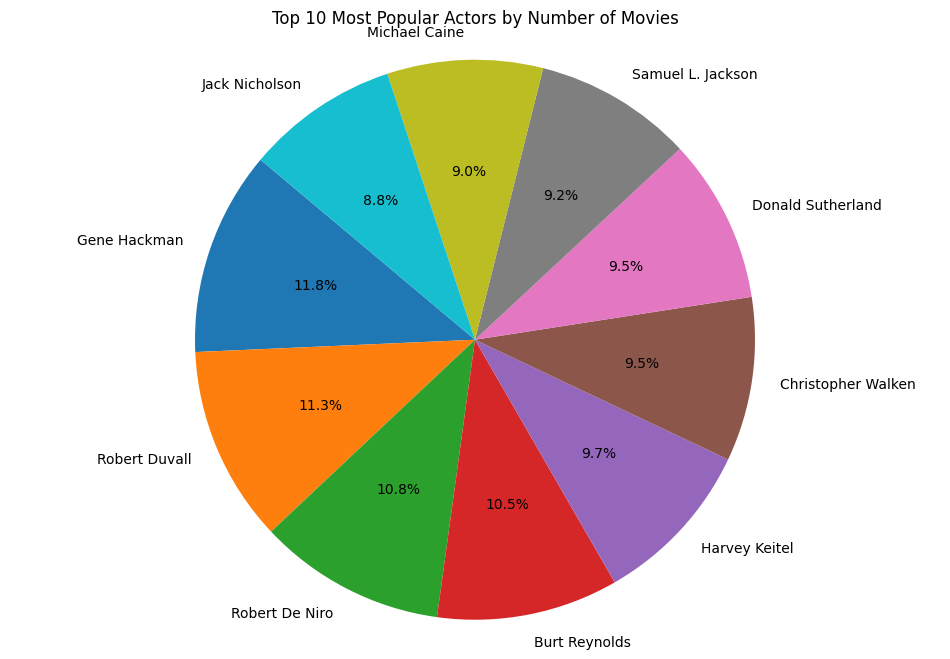

In [ ]:
# Налаштування розміру графіка
plt.figure(figsize=(12, 8))

# Побудова кругової діаграми
# x=кількість фільмів, labels=імена акторів, autopct=відсотки
plt.pie(top_actors['movies_count'], labels=top_actors['actor'], autopct='%1.1f%%', startangle=140)

# Додаємо заголовок (точно як на скриншоті)
plt.title('Top 10 Most Popular Actors by Number of Movies')

# Рівний аспект, щоб коло було круглим
plt.axis('equal')

# Показуємо графік
plt.show()

8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [ ]:
# Перетворюємо колонку з акторами на списки Python (якщо ще не зроблено)
df["cast"] = df["cast"].apply(lambda x: x if isinstance(x, list) else [])

# Розпаковуємо списки акторів, щоб кожен рядок відповідав одному елементу
df_exploded_cast = df.explode("cast")

# Визначаємо топ-3 акторів за частотою появи
top_actors_list = df_exploded_cast["cast"].value_counts().head(3).index.tolist()

# Фільтруємо DataFrame, залишаємо тільки записи з обраними акторами
df_top = df[df["cast"].apply(lambda x: any(actor in x for actor in top_actors_list))]

# Перевіряємо результат
df_top.head()

,title,year,cast,genres
470,To Kill a Mockingbird,1962,"[Gregory Peck, Mary Badham, Phillip Alford, Ro...","[Drama, Legal]"
507,"Captain Newman, M.D.",1963,"[Gregory Peck, Angie Dickinson, Tony Curtis, E...","[Drama, Comedy]"
982,The Chase,1966,"[Marlon Brando, Jane Fonda, Robert Redford, An...",[Drama]
1017,Hawaii,1966,"[Julie Andrews, Max von Sydow, Richard Harris,...",[Drama]
1117,Bonnie and Clyde,1967,"[Warren Beatty, Faye Dunaway, Gene Hackman, Es...","[Crime, Drama, Noir, Biography]"


In [ ]:
# Створюємо порожній список для зберігання зв'язків "актор-фільм"
rows = []

# Проходимо по кожному фільму з відфільтрованого df_top
for _, row in df_top.iterrows():
    # Перебираємо акторів у фільмі
    for actor in row["cast"]:
        # Залишаємо лише обраних акторів
        if actor in top_actors_list:
            # Додаємо інформацію у список
            rows.append({"year": row["year"], "actor": actor})

# Створюємо DataFrame з отриманих даних
actors_df = pd.DataFrame(rows)

# Виводимо результат
print(actors_df.head())

   year          actor
0  1962  Robert Duvall
1  1963  Robert Duvall
2  1966  Robert Duvall
3  1966   Gene Hackman
4  1967   Gene Hackman


In [ ]:
# Групуємо дані за актором і роком
actor_year_stats = (
    actors_df.groupby(['year', 'actor'])
    .size() # рахуємо кількість фільмів для кожної групи
    .reset_index(name='movies_count') # перетворюємо у таблицю
    .sort_values(by='year') # сортуємо за роками
)

# Виводимо частину результату для перевірки
print(actor_year_stats.head())

   year          actor  movies_count
0  1962  Robert Duvall             1
1  1963  Robert Duvall             1
2  1966   Gene Hackman             1
3  1966  Robert Duvall             1
4  1967   Gene Hackman             2


In [ ]:
# Перетворюємо actor_year_stats у широку таблицю
# Рядки — роки, колонки — актори, значення — кількість фільмів
# Пропуски заповнюємо нулями (.fillna(0))
pivot_df = actor_year_stats.pivot(index='year', columns='actor', values='movies_count').fillna(0)

# Перевіряємо частину результату
pivot_df.head()

actor,Gene Hackman,Robert De Niro,Robert Duvall
year,,,
1962,0.0,0.0,1.0
1963,0.0,0.0,1.0
1966,1.0,0.0,1.0
1967,2.0,0.0,0.0
1968,1.0,1.0,1.0


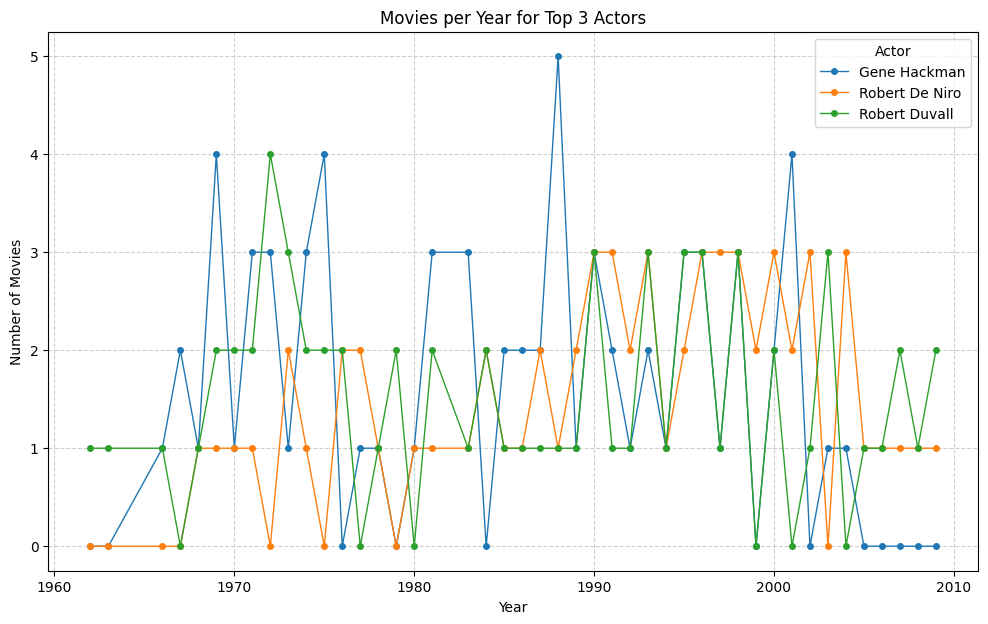

In [ ]:
# Будуємо лінійний графік з маркерами
pivot_df.plot(figsize=(12, 7), marker='o', linestyle='-', linewidth=1, markersize=4)

# Додаємо оформлення як на зразку
plt.title('Movies per Year for Top 3 Actors')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.legend(title='Actor')
plt.grid(True, linestyle='--', alpha=0.6)

# Відображаємо графік
plt.show()

***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

In [ ]:
# 1. Визначаємо ТОП-3 жанри
top3_genres = set(genre_counts['genre'].head(3).tolist())

# 2. Визначаємо ТОП-10 акторів
top10_actors = actor_counts['actor'].head(10).tolist()

print(f"Топ жанри: {top3_genres}")
print(f"Топ актори: {top10_actors}")

Топ жанри: {'Action', 'Drama', 'Comedy'}
Топ актори: ['Gene Hackman', 'Robert Duvall', 'Robert De Niro', 'Burt Reynolds', 'Harvey Keitel', 'Christopher Walken', 'Donald Sutherland', 'Samuel L. Jackson', 'Michael Caine', 'Jack Nicholson']


In [ ]:
bonus_stats = []

for actor in top10_actors:
    # Фільтруємо всі фільми, де знімався цей конкретний актор
    actor_movies = df[df['cast'].apply(lambda x: actor in x)]

    total_movies = len(actor_movies)

    # Рахуємо фільми, де хоча б один жанр входить у топ-3
    in_top_genre = actor_movies['genres'].apply(lambda g: any(genre in top3_genres for genre in g)).sum()

    # Решта фільмів (не в топ-жанрах)
    not_in_top_genre = total_movies - in_top_genre

    # Відсоток для таблиці
    percentage = (in_top_genre / total_movies * 100) if total_movies > 0 else 0

    bonus_stats.append({
        'actor': actor,
        'In Top Genre': in_top_genre,
        'Other Genres': not_in_top_genre,
        'Top Genre %': round(percentage, 2)
    })

# Перетворюємо у DataFrame
bonus_df = pd.DataFrame(bonus_stats)
display(bonus_df)

,actor,In Top Genre,Other Genres,Top Genre %
0,Gene Hackman,48,23,67.61
1,Robert Duvall,52,16,76.47
2,Robert De Niro,56,9,86.15
3,Burt Reynolds,55,8,87.30
4,Harvey Keitel,50,8,86.21
5,Christopher Walken,44,13,77.19
6,Donald Sutherland,42,15,73.68
7,Samuel L. Jackson,38,17,69.09
8,Michael Caine,38,16,70.37
9,Jack Nicholson,39,14,73.58


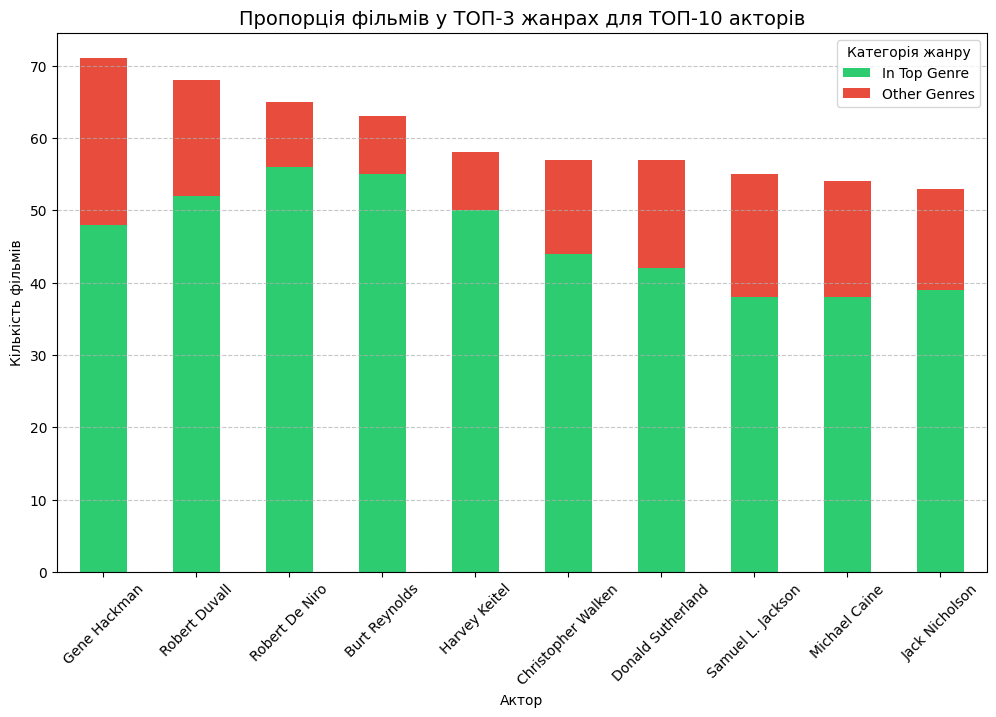

In [ ]:
# Встановлюємо актора як індекс для зручності побудови графіка
plot_df = bonus_df.set_index('actor')[['In Top Genre', 'Other Genres']]

# Будуємо графік
plot_df.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#2ecc71', '#e74c3c'])

# Додаємо оформлення
plt.title('Пропорція фільмів у ТОП-3 жанрах для ТОП-10 акторів', fontsize=14)
plt.xlabel('Актор')
plt.ylabel('Кількість фільмів')
plt.legend(title='Категорія жанру')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()